In [1]:
# ==========================================
#  LEAN VALUE STREAM ANALYSIS – EMERGENCY DEPARTMENT
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ----------------------------
# 1. Load and clean data
# ----------------------------
df = pd.read_csv("../data/emergency_service.csv", delimiter=";", encoding="latin1")

# converting numeric columns
for col in ["Length of stay_min", "KTAS duration_min"]:
    df[col] = (
        df[col].astype(str).str.replace(",", ".", regex=False).astype(float)
    )

# removing missing or unrealistic values
df = df.dropna(subset=["Length of stay_min", "KTAS duration_min"])
df = df[df["Length of stay_min"] <= 720]  # to filter out extreme outliers


In [3]:
# ----------------------------
# 2. Calculate process components
# ----------------------------
df["Waiting_time_min"] = df["Length of stay_min"] - df["KTAS duration_min"]
df["Waiting_time_min"] = df["Waiting_time_min"].clip(lower=0)  # no negative waits

# Value-Added (VA) = triage duration
# Non–Value-Added (NVA) = waiting time
df["VA"] = df["KTAS duration_min"]
df["NVA"] = df["Waiting_time_min"]


In [4]:
# ----------------------------
# 3. Summarize system performance
# ----------------------------
total_VA = df["VA"].sum()
total_NVA = df["NVA"].sum()
pct_VA = total_VA / (total_VA + total_NVA) * 100
pct_NVA = 100 - pct_VA

print("--- Process Time Summary ---")
print(f"Total Value-Added Time: {total_VA:.1f} min ({pct_VA:.2f}%)")
print(f"Total Non-Value-Added Time: {total_NVA:.1f} min ({pct_NVA:.2f}%)")

--- Process Time Summary ---
Total Value-Added Time: 5942.3 min (2.51%)
Total Non-Value-Added Time: 230980.7 min (97.49%)


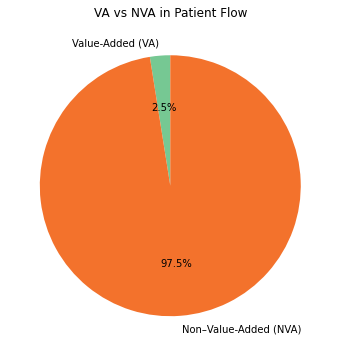

In [5]:
# ----------------------------
# 4. Visualize Value vs Non-Value Added
# ----------------------------
plt.figure(figsize=(6,6))
plt.pie(
    [total_VA, total_NVA],
    labels=["Value-Added (VA)", "Non–Value-Added (NVA)"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#76c893", "#f3722c"],
)
plt.title("VA vs NVA in Patient Flow")
plt.show()


--- Average Waiting (NVA) by Group ---
   Group   mean_VA    mean_NVA
1      2  3.037152  328.390093
0      1  7.517076  189.258682


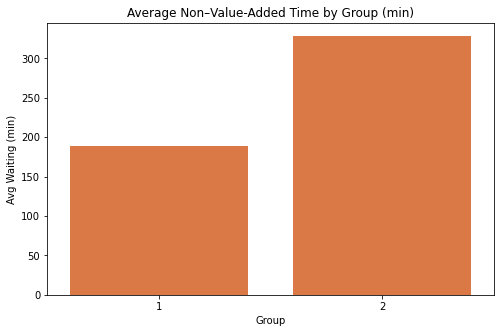

In [ ]:
# ----------------------------
# 5. Identify bottlenecks (by Group or Error Group)
# ----------------------------
group_perf = (
    df.groupby("Group", as_index=False)
    .agg(mean_VA=("VA", "mean"), mean_NVA=("NVA", "mean"))
    .sort_values("mean_NVA", ascending=False)
)

print("\n--- Average Waiting (NVA) by Group ---")
print(group_perf)

# visualization
plt.figure(figsize=(8,5))
sns.barplot(data=group_perf, x="Group", y="mean_NVA", color="#f3722c")
plt.title("Average Non–Value-Added Time by Group (min)")
plt.ylabel("Avg Waiting (min)")
plt.xlabel("Group")
plt.show()


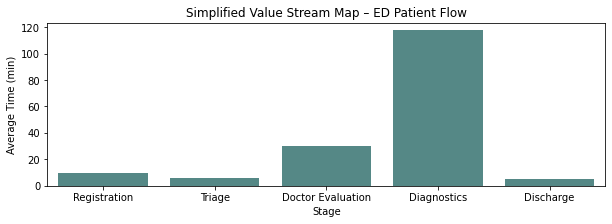

In [ ]:
# ----------------------------
# 6. Simple Value Stream Map (simplified stages)
# ----------------------------
# simulating process stages
stages = ["Registration", "Triage", "Doctor Evaluation", "Diagnostics", "Discharge"]
times = [10, df["VA"].mean(), 30, df["NVA"].mean()/2, 5]

vsm_df = pd.DataFrame({"Stage": stages, "Avg Time (min)": times})

plt.figure(figsize=(10,3))
sns.barplot(data=vsm_df, x="Stage", y="Avg Time (min)", color="#4d908e")
plt.title("Simplified Value Stream Map – ED Patient Flow")
plt.ylabel("Average Time (min)")
plt.show()


In [ ]:
# ----------------------------
# 7. Efficiency Metrics
# ----------------------------
# little's Law metrics (throughput approximations)
mean_LOS = df["Length of stay_min"].mean()
mean_wait = df["Waiting_time_min"].mean()
lean_efficiency = pct_VA / 100

print("\n--- Lean Efficiency Metrics ---")
print(f"Average LOS: {mean_LOS:.2f} min")
print(f"Average Waiting Time: {mean_wait:.2f} min")
print(f"Process Efficiency (VA%): {lean_efficiency*100:.1f}%")

if lean_efficiency < 0.2:
    print("⚠️ Very low process efficiency – high waste and delay potential.")
elif lean_efficiency < 0.5:
    print("⚠️ Moderate efficiency – improvement needed (waiting dominates).")
else:
    print("✅ Good flow balance – process largely value-driven.")


--- Lean Efficiency Metrics ---
Average LOS: 240.84 min
Average Waiting Time: 234.98 min
Process Efficiency (VA%): 2.5%
⚠️ Very low process efficiency – high waste and delay potential.
